# Exploratory System-Level Analysis of Object Similarity Using Visual Embeddings

This notebook contains exploratory analysis used to evaluate system-level design choices for instance-level object similarity, including cropping strategy, similarity measurement, thresholding, and ambiguity handling.

The purpose of this analysis is to inform the design of the final system. It is not intended as model benchmarking or final implementation code.

Since this is to check if my system works as intended and also to isolate the system design choices, the visual embedding model will be fixed to CLIP(vit-b/32) and then as per project guidelines, the computation is set to CPU. 

In [48]:
import torch
import clip
from PIL import Image

device = "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
print("Model loaded")


Model loaded


## Helper functions

As per mentioned in the design portion, cosine similarity will be used for the evaluation of the embeddings and then a get embedding function will be created to get the values.

To ensure the input meets the model's specific requirements, the preprocess function, when called inside get_embedding, allows the model to take a fixed-size square from the center of the image it receives, alongside resizing and normalization. This standardization ensures that the correct parameters are passed into the neural network for consistent feature generation.

In [ ]:
import torch
import torch.nn.functional as F


def get_embedding(img):
    img_tensor = preprocess(img).unsqueeze(0).to(device)
    # gradient calculation is not needed
    with torch.no_grad():
        embedding = model.encode_image(img_tensor)
    # normalization 
    embedding = embedding / embedding.norm(dim=-1, keepdim=True)
    return embedding.squeeze(0)

def cosine_similarity(e1, e2):
    return F.cosine_similarity(e1, e2, dim=0).item()


The similarity computation function opens up a pair of images and then generates their embeddings and calculates their cosine similarity between them. This score will be used as a basis to determine if the pair of objects are simliar or different. 

In [ ]:
def compute_similarities(pairs):
    scores = []
    for pair_id, paths in pairs.items():
        img1 = Image.open(paths[0]).convert("RGB")
        img2 = Image.open(paths[1]).convert("RGB")

        e1 = get_embedding(img1)
        e2 = get_embedding(img2)

        sim = cosine_similarity(e1, e2)
        scores.append(sim)
    return scores


## Photo loading for baseline test

Photos from 2 different files will be loaded, the photos in the "same" folder will contain pairs of photos that contain the same object but in a different environment and angle while the photos in the "different" folder will contain pairs of photos that contain two different objects but same type taken in the same position and environment

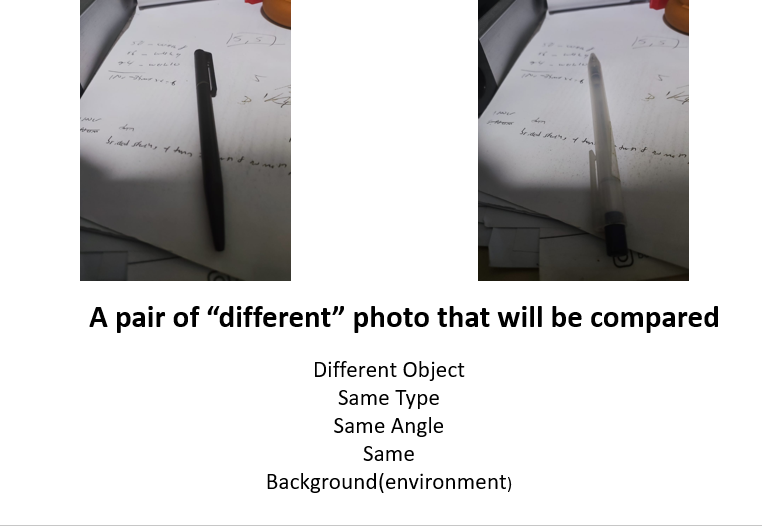

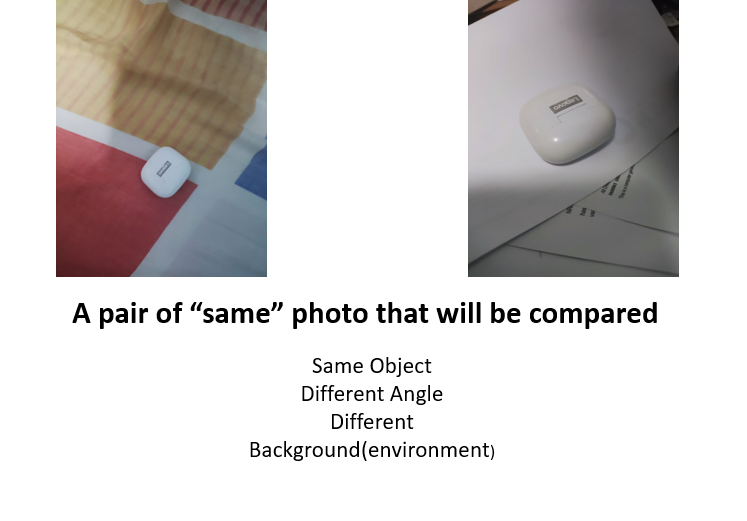

In [ ]:
import os
# seperating the photos by their file names so that the correct photos can be compared
def load_pairs(folder):
    files = sorted(os.listdir(folder))
    pairs = {}

    for f in files:
        pair_id = f.split("_")[0]
        pairs.setdefault(pair_id, []).append(os.path.join(folder, f))

    return pairs


In [51]:
same_pairs = load_pairs("photos/same")
diff_pairs = load_pairs("photos/different")

print(same_pairs)
print(diff_pairs)


{'pair01': ['photos/same\\pair01_a.jpeg', 'photos/same\\pair01_b.jpeg'], 'pair02': ['photos/same\\pair02_a.jpeg', 'photos/same\\pair02_b.jpeg'], 'pair05': ['photos/same\\pair05_a.jpeg', 'photos/same\\pair05_b.jpeg'], 'pair08': ['photos/same\\pair08_a.jpeg', 'photos/same\\pair08_b.jpeg']}
{'pair03': ['photos/different\\pair03_a.jpeg', 'photos/different\\pair03_b.jpeg'], 'pair04': ['photos/different\\pair04_a.jpeg', 'photos/different\\pair04_b.jpeg'], 'pair06': ['photos/different\\pair06_a.jpeg', 'photos/different\\pair06_b.jpeg'], 'pair07': ['photos/different\\pair07_a.jpeg', 'photos/different\\pair07_b.jpeg']}


## Baseline Test

The baseline test is just to ensure that the embedding model works and that a cosine similarity score will be calculated

In [53]:
same_scores = compute_similarities(same_pairs)
diff_scores = compute_similarities(diff_pairs)

print("Same scores:", same_scores)
print("Different scores:", diff_scores)


Same scores: [0.9307599067687988, 0.8866268992424011, 0.8201878070831299, 0.8003036379814148]
Different scores: [0.9349400997161865, 0.8811296820640564, 0.8683475255966187, 0.8776703476905823]


The results will be plotted as a scatter graph. A slight jitter would be added to prevent overlap if the similarity score is exactly the same 

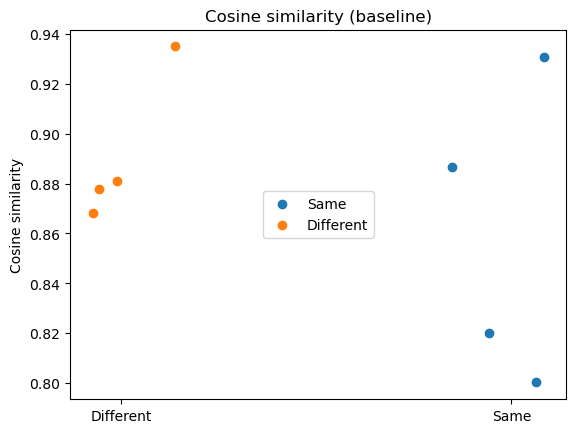

In [54]:
import numpy as np
import matplotlib.pyplot as plt

same = np.array(same_scores, dtype=float)
diff = np.array(diff_scores, dtype=float)

j = 0.06  # jitter amount

plt.scatter(np.random.normal(1, j, size=len(same)), same, label="Same")
plt.scatter(np.random.normal(0, j, size=len(diff)), diff, label="Different")

plt.xticks([0, 1], ["Different", "Same"])
plt.ylabel("Cosine similarity")
plt.title("Cosine similarity (baseline)")
plt.legend(loc="center")
plt.show()



Since 16 photos are uploaded, that means that by right there should be 8 similarity scores, as every photo is compared with one other photo. As can be seen from the graph, there are 8 points which shows that the embedding model did work and all of the scores are produced

In terms of similarity scores however, it leaves more to be desired since somehow looking at the overall trend of the graph the similarity score for a different pair of photo is higher than a same pair of photo. The pair of photos that contain the same object should by right have a higher score than the two different objects (same type and same environment) since they are the same object. This shows that maybe environment plays a much bigger role and that cropping is essential.

For object detection models, the output already includes an implied crop via the bounding box, however, the tightness of these boxes needs to be studied to see if there is an impact on embedding similarity

## Impact of Loose vs Tight Cropping on Cosine Similarity

One pair of photos with the same object but different environment and another pair with the different object but same type and same environment will be used. They will be used and compared in three different ways, the original crop, a loose crop and a tight crop. 

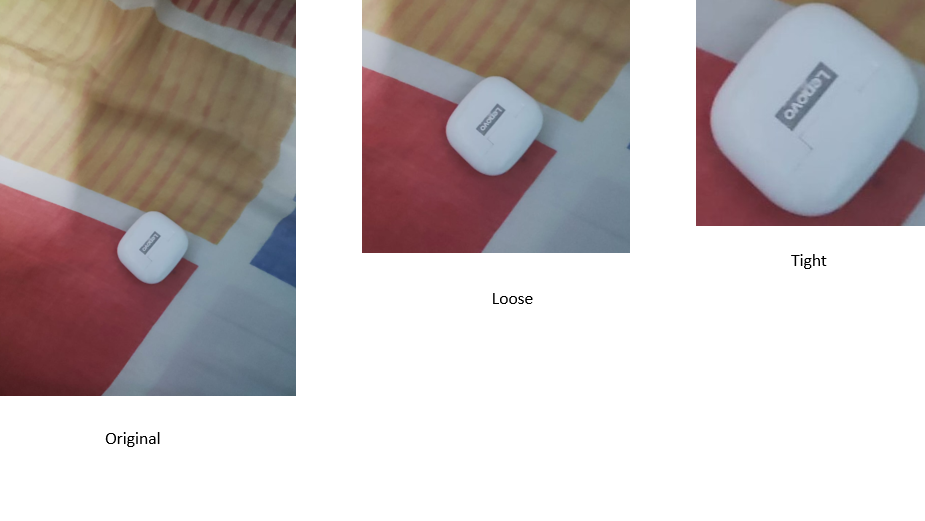


These cropped images above will be compared only with their respective matching crop from the corresponding pair image (i.e., Original vs. Original, Loose vs. Loose, and Tight vs. Tight).

In [ ]:
from pathlib import Path
from collections import defaultdict

def load_pairs_by_mode(folder):
    # creating a dictionary
    pairs = defaultdict(lambda: defaultdict(dict))
    folder = Path(folder)
    # iterate through files and split the photos accordingly
    for path in folder.iterdir():
        if path.suffix != ".jpeg":
            continue

        stem = path.stem             
        parts = stem.split("_")

        pair_id = parts[0]            
        side = parts[1]               
        mode = "original" if len(parts) == 2 else parts[2]

        pairs[pair_id][mode][side] = path

    return pairs


In [56]:
same_pairs = load_pairs_by_mode("cropped_photos/same")
diff_pairs = load_pairs_by_mode("cropped_photos/different")


In [ ]:
from PIL import Image
# similarity function same as above but this time inclusive of the mode so that it can be reiterated
def compute_similarities(pairs, mode):
    scores = []

    for pair_id, modes in pairs.items():
        if mode not in modes:
            continue

        img_a = Image.open(modes[mode]["a"]).convert("RGB")
        img_b = Image.open(modes[mode]["b"]).convert("RGB")

        e1 = get_embedding(img_a)
        e2 = get_embedding(img_b)

        scores.append(cosine_similarity(e1, e2))

    return scores


similarities will be computed for all three scenarios and plotted

In [58]:
same_orig = compute_similarities(same_pairs, "original")
diff_orig = compute_similarities(diff_pairs, "original")

same_loose = compute_similarities(same_pairs, "loose")
diff_loose = compute_similarities(diff_pairs, "loose")

same_tight = compute_similarities(same_pairs, "tight")
diff_tight = compute_similarities(diff_pairs, "tight")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_crop_comparison(data, title):
    x_positions = []
    y_values = []
    labels = []

    x = 0
    for label, (same, diff) in data.items():
        # ploting "different" scores and include jitter
        x_positions += list(np.random.normal(x, 0.04, size=len(diff)))
        y_values += diff
        labels += ["Different"] * len(diff)

        # plotting "same" scores and include jitter as well
        x_positions += list(np.random.normal(x + 0.3, 0.04, size=len(same)))
        y_values += same
        labels += ["Same"] * len(same)

        x += 1
    # colors assignment for better visibility
    colors = ["tab:orange" if l == "Different" else "tab:blue" for l in labels]

    plt.scatter(x_positions, y_values, c=colors, alpha=0.8)
    plt.xticks([0.15, 1.15, 2.15], ["Baseline", "Loose", "Tight"])
    plt.ylabel("Cosine similarity")
    plt.title(title)

    # legend including name and color
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker="o", color="w", label="Same",
               markerfacecolor="tab:blue", markersize=8),
        Line2D([0], [0], marker="o", color="w", label="Different",
               markerfacecolor="tab:orange", markersize=8),
    ]
    plt.legend(handles=legend_elements, loc="center left")

    plt.show()


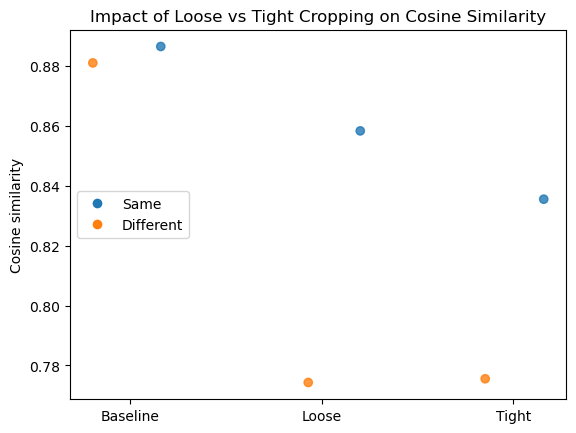

In [60]:
plot_crop_comparison(
    {
        "Baseline": (same_orig, diff_orig),
        "Loose": (same_loose, diff_loose),
        "Tight": (same_tight, diff_tight),
    },
    title="Impact of Loose vs Tight Cropping on Cosine Similarity"
)


As can be seen from the gap between same-object and different-object similarity scores across the three crop conditions, applying cropping improves separation compared to the full-frame baseline. This indicates that reducing background influence aids in differentiating between similar and different objects. By focusing similarity computation on object-centric crops, the system increases the gap between same and different similarities, enabling more reliable decision boundaries. For this specific object pair, loose cropping produced a larger separation than tight cropping, suggesting that retaining a limited amount of surrounding context can be beneficial for embedding-based discrimination in certain scenarios.

This means that after evaluation of the embedding model and the detection model and the best models are chosen, the crops should be tested as well, since sometimes based on the model, looser crop gives better results than a tight crop

## Similarity Threshold

The embedding model does not automatically determine whether two objects are the same or different, it only outputs a similarity score. Therefore, a decision threshold must be defined externally to convert similarity values into system actions.

Thresholds are calibrated from the observed similarity distributions. The highest similarity observed among different-object comparisons is used as a conservative lower bound, while the lowest similarity observed among same-object comparisons is used as an upper bound. The difference between these values defines a separation gap. A safety margin is applied within this gap to form two thresholds, resulting in three decision regions: confident match, confident non-match, and an ambiguous region.

In [ ]:
import numpy as np

def calibrate_thresholds(same_scores, diff_scores, margin_frac=0.25):
    same = np.array(same_scores, dtype=float)
    diff = np.array(diff_scores, dtype=float)

    LOW = diff.max()
    HIGH = same.min()

    gap = HIGH - LOW
    if gap <= 0:
        T_LOW = LOW
        T_HIGH = HIGH
    else:
        # adding some buffer margin so that values in that range will be accepted as either same or different
        margin = margin_frac * gap
        T_LOW = LOW + margin
        T_HIGH = HIGH - margin

    return float(T_LOW), float(T_HIGH), float(LOW), float(HIGH), float(gap)

T_LOW, T_HIGH, LOW, HIGH, gap = calibrate_thresholds(same_loose, diff_loose)

print("diff max (LOW):", round(LOW, 2))
print("same min (HIGH):", round(HIGH, 2))
print("gap:", round(gap, 2))
print("T_LOW:", round(T_LOW, 2))
print("T_HIGH:", round(T_HIGH, 2))



diff max (LOW): 0.77
same min (HIGH): 0.86
gap: 0.08
T_LOW: 0.8
T_HIGH: 0.84


## Issue of ambiguity

A graph will be plotted using the results from the loose crop to see the seperation of the gaps

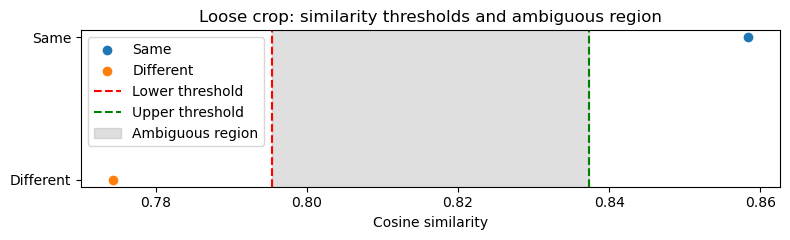

In [65]:
import matplotlib.pyplot as plt
import numpy as np

same = np.array(same_loose, dtype=float)
diff = np.array(diff_loose, dtype=float)

plt.figure(figsize=(8, 2.5))

# Plot points on a single horizontal line
plt.scatter(same, np.ones_like(same), label="Same", color="tab:blue", zorder=3)
plt.scatter(diff, np.zeros_like(diff), label="Different", color="tab:orange", zorder=3)

# Draw threshold lines
plt.axvline(T_LOW, linestyle="--", color="red", label="Lower threshold")
plt.axvline(T_HIGH, linestyle="--", color="green", label="Upper threshold")

# Shade ambiguous region
plt.axvspan(T_LOW, T_HIGH, color="gray", alpha=0.25, label="Ambiguous region")

plt.yticks([0, 1], ["Different", "Same"])
plt.xlabel("Cosine similarity")
plt.title("Loose crop: similarity thresholds and ambiguous region")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


As illustrated in the threshold plot, similarity scores falling between the lower and upper limits form an ambiguous region(grey area) where it is not possible to reliably determine whether two objects are the same or different. This ambiguity poses a risk for the system, as incorrectly assuming a match(same object) would overwrite the stored location of an existing object. If the compared objects are in fact different, this would result in the user being unable to locate the original object. To prevent this failure mode, comparisons that fall within the ambiguous region are handled conservatively by creating a new object entry rather than replacing an existing one, prioritizing reliability over aggressive matching.

In [2]:
def decide(sim, T_LOW, T_HIGH):
    if sim >= T_HIGH:
        return "same"
    if sim <= T_LOW:
        return "new"
    # if not same or different that means that it falls under the ambiguous region and thus should be regarded as new to prevent false positive
    return "new"

In [63]:
print("\nLoose SAME decisions")
for s in same_loose:
    print(round(s, 2), "->", decide(s, T_LOW, T_HIGH))

print("\nLoose DIFFERENT decisions")
for s in diff_loose:
    print(round(s, 2), "->", decide(s, T_LOW, T_HIGH))



Loose SAME decisions
0.86 -> same

Loose DIFFERENT decisions
0.77 -> new


In [6]:
T_LOW = 0.8
T_HIGH = 0.84
# test if the similarity score is within the grey zone
s = 0.82
print(decide(s, T_LOW, T_HIGH))

new


## Conclusion

This exploratory analysis successfully validated the core technical feature of the system: the ability to generate visual embeddings and calculate instance-level similarity using the CLIP (ViT-B/32) model and cosine similarity.

However, the full-frame baseline test demonstrated that relying solely on the raw model output is insufficient. The suboptimal scores and significant overlap between 'same' and 'different' object comparisons confirmed that environmental and background context unduly influence the embeddings.

The subsequent feasibility tests validated the primary system design adjustment:

1. Cropping is Essential: Applying object-centric cropping significantly improved the separation gap between 'same' and 'different' object score distributions, confirming the necessity of reducing background noise, thus proving the need for the object detection model which will be used to get the bounding boxes of the objects.

2. Crop Tightness is a Key Parameter: The evaluation across different crop modes (loose vs. tight) demonstrated that the quality of the bounding box crop must be optimized. This confirms that the final system must account for the optimal external parameter, the crop tightness to achieve the best discriminatory performance.

Finally, the analysis established the necessity of a layered decision process:

1. Thresholding is Required: Raw similarity scores lack utility without defining external decision thresholds ($T_{\text{LOW}}$ and $T_{\text{HIGH}}$) to translate them into actionable system decisions ("same" or "new").

2. Ambiguity is Handled Conservatively: The existence of an ambiguous region between the thresholds was identified. To mitigate the high-risk failure mode of a False Positive (incorrectly overwriting a known object's location), the system will employ a conservative decision strategy by classifying any score within this ambiguous region as a "new object." This choice ensures data integrity and operational reliability are prioritized over aggressive matching.
